# Análise Exploratória de Dados (EDA) - Previsão de Ações Nike (NKE)

## Objetivo
Este projeto tem como objetivo analisar o comportamento histórico das ações da Nike (NKE) e preparar os dados para um modelo de previsão baseado em LSTM.

A análise exploratória (EDA) busca:
- Entender padrões temporais do preço
- Avaliar volatilidade e comportamento dos retornos
- Identificar tendências e possíveis features relevantes
- Justificar decisões de modelagem

## Contexto de Negócio
A previsão de preços de ações pode auxiliar:
- Tomada de decisão de investimento
- Gestão de risco
- Estratégias automatizadas de trading

Importante: O mercado financeiro é altamente volátil e imprevisível, portanto os modelos têm limitações inerentes.

In [1]:
from datetime import datetime
from dateutil.relativedelta import relativedelta

import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
pd.set_option("display.max_columns", None)


In [2]:
FEATURE_COLS_DEFAULT = [
    "close",
    "return_1d",
    "ma_5_ratio",
    "ma_20_ratio",
    "volatility_10",
    "volume_zscore_20",
]


def download_nike_data_for_eda(ticker="NKE", months=60):
    """
    Baixa os dados em memória, sem salvar CSV em disco.
    """
    today = datetime.today()
    start_date = today - relativedelta(months=months)

    df = yf.download(
        ticker,
        start=start_date.strftime("%Y-%m-%d"),
        end=today.strftime("%Y-%m-%d"),
        auto_adjust=True,
        progress=False,
    )

    df = df.reset_index()
    return df


def create_processed_data_for_eda(df: pd.DataFrame) -> pd.DataFrame:
    """
    Replica a lógica principal de preparação, mas inteiramente dentro do notebook.
    Não salva arquivos intermediários.
    """
    df = df.copy()

    df.columns = [
        "_".join(str(c) for c in col if c is not None).lower()
        if isinstance(col, tuple)
        else str(col).lower()
        for col in df.columns
    ]

    rename_map = {}
    for col in df.columns:
        if "date" in col:
            rename_map[col] = "date"
        elif "open" in col:
            rename_map[col] = "open"
        elif "high" in col:
            rename_map[col] = "high"
        elif "low" in col:
            rename_map[col] = "low"
        elif "close" in col:
            rename_map[col] = "close"
        elif "volume" in col:
            rename_map[col] = "volume"

    df = df.rename(columns=rename_map)
    df = df.loc[:, ~df.columns.duplicated()]

    if "date" in df.columns:
        df["date"] = pd.to_datetime(df["date"], errors="coerce")
        df = df.sort_values("date")

    numeric_cols = [c for c in ["open", "high", "low", "close", "volume"] if c in df.columns]
    for col in numeric_cols:
        df[col] = pd.to_numeric(df[col], errors="coerce")

    df = df.dropna(subset=["close"]).reset_index(drop=True)

    df["return_1d"] = df["close"].pct_change()
    df["ma_5"] = df["close"].rolling(5).mean()
    df["ma_20"] = df["close"].rolling(20).mean()
    df["ma_5_ratio"] = df["close"] / df["ma_5"] - 1.0
    df["ma_20_ratio"] = df["close"] / df["ma_20"] - 1.0
    df["volatility_10"] = df["return_1d"].rolling(10).std()

    if "volume" in df.columns:
        vol_mean_20 = df["volume"].rolling(20).mean()
        vol_std_20 = df["volume"].rolling(20).std()
        df["volume_zscore_20"] = (df["volume"] - vol_mean_20) / vol_std_20.replace(0, np.nan)
    else:
        df["volume_zscore_20"] = 0.0

    df["target_return_1d"] = df["close"].shift(-1) / df["close"] - 1.0

    df = df.replace([np.inf, -np.inf], np.nan)
    df = df.dropna().reset_index(drop=True)

    return df


In [3]:
raw_df = download_nike_data_for_eda(ticker="NKE", months=60)
df = create_processed_data_for_eda(raw_df)

print("Shape raw:", raw_df.shape)
print("Shape processed:", df.shape)
print("Colunas disponíveis:", df.columns.tolist())
df.head()


Shape raw: (1255, 6)
Shape processed: (1235, 14)
Colunas disponíveis: ['date', 'close', 'high', 'low', 'open', 'volume', 'return_1d', 'ma_5', 'ma_20', 'ma_5_ratio', 'ma_20_ratio', 'volatility_10', 'volume_zscore_20', 'target_return_1d']


,date,close,high,low,open,volume,return_1d,ma_5,ma_20,ma_5_ratio,ma_20_ratio,volatility_10,volume_zscore_20,target_return_1d
0,2021-04-29,123.528084,124.325279,121.646335,122.146907,6612500,0.019509,121.965205,123.172578,0.012814,0.002886,0.018516,-0.237347,-0.004803
1,2021-04-30,122.934807,124.102799,122.406441,122.767959,5643600,-0.004803,122.415714,123.176749,0.004240,-0.001964,0.018480,-0.757140,0.003092
2,2021-05-03,123.314873,124.631169,122.907003,123.630039,5053000,0.003092,122.680823,123.079879,0.005168,0.001909,0.018029,-1.050414,-0.011125
3,2021-05-04,121.942955,122.906998,120.951090,122.573288,6129500,-0.011125,122.577003,122.819862,-0.005173,-0.007140,0.011703,-0.535762,0.005017
4,2021-05-05,122.554749,124.417954,122.434238,123.008955,6234200,0.005017,122.855093,122.619173,-0.002445,-0.000525,0.009809,-0.464495,0.009682


## Visão Geral dos Dados

Nesta seção analisamos:
- Quantidade de registros
- Tipos de dados
- Valores nulos
- Duplicatas

In [4]:
print("Shape:", df.shape)
df.info()

Shape: (1235, 14)
<class 'pandas.DataFrame'>
RangeIndex: 1235 entries, 0 to 1234
Data columns (total 14 columns):
 #   Column            Non-Null Count  Dtype        
---  ------            --------------  -----        
 0   date              1235 non-null   datetime64[s]
 1   close             1235 non-null   float64      
 2   high              1235 non-null   float64      
 3   low               1235 non-null   float64      
 4   open              1235 non-null   float64      
 5   volume            1235 non-null   int64        
 6   return_1d         1235 non-null   float64      
 7   ma_5              1235 non-null   float64      
 8   ma_20             1235 non-null   float64      
 9   ma_5_ratio        1235 non-null   float64      
 10  ma_20_ratio       1235 non-null   float64      
 11  volatility_10     1235 non-null   float64      
 12  volume_zscore_20  1235 non-null   float64      
 13  target_return_1d  1235 non-null   float64      
dtypes: datetime64[s](1), float64(12),

In [5]:
df.isnull().sum().sort_values(ascending=False)

date                0
close               0
high                0
low                 0
open                0
volume              0
return_1d           0
ma_5                0
ma_20               0
ma_5_ratio          0
ma_20_ratio         0
volatility_10       0
volume_zscore_20    0
target_return_1d    0
dtype: int64

In [6]:
df.describe()

,date,close,high,low,open,volume,return_1d,ma_5,ma_20,ma_5_ratio,ma_20_ratio,volatility_10,volume_zscore_20,target_return_1d
count,1235,1235.000000,1235.000000,1235.000000,1235.000000,1.235000e+03,1235.000000,1235.000000,1235.000000,1235.000000,1235.000000,1235.000000,1235.000000,1235.000000
mean,2023-10-12 03:13:33,97.739372,98.849054,96.685302,97.766556,1.049775e+07,-0.000451,97.852815,98.269710,-0.001293,-0.005706,0.019445,0.015094,-0.000441
min,2021-04-29 00:00:00,51.240002,52.110001,50.950001,51.430000,2.443600e+06,-0.199809,52.230000,54.626500,-0.172740,-0.198873,0.005228,-2.596813,-0.199809
25%,2022-07-20 12:00:00,73.999809,74.816415,72.942071,74.020740,6.023950e+06,-0.010899,73.887968,74.283106,-0.014547,-0.038867,0.012407,-0.662009,-0.010899
50%,2023-10-11 00:00:00,97.169891,98.149127,96.216831,97.122206,8.305000e+06,-0.000561,97.405893,98.101258,-0.001019,-0.003724,0.016586,-0.259073,-0.000561
75%,2025-01-02 12:00:00,115.538975,117.155942,114.057297,115.792631,1.223330e+07,0.010299,115.474384,115.878752,0.012454,0.027548,0.023172,0.399239,0.010299
max,2026-03-30 00:00:00,165.150650,166.629955,163.280604,164.071386,1.299670e+08,0.155314,162.093433,159.441384,0.134095,0.193491,0.069619,4.196087,0.155314
std,NaN,28.014605,28.195841,27.807202,28.012454,8.954542e+06,0.022094,27.906956,27.553233,0.023867,0.053532,0.010595,1.076442,0.022105


## Evolução do Preço de Fechamento

O preço de fechamento (`close`) é a principal variável alvo do modelo.
Vamos observar seu comportamento ao longo do tempo.

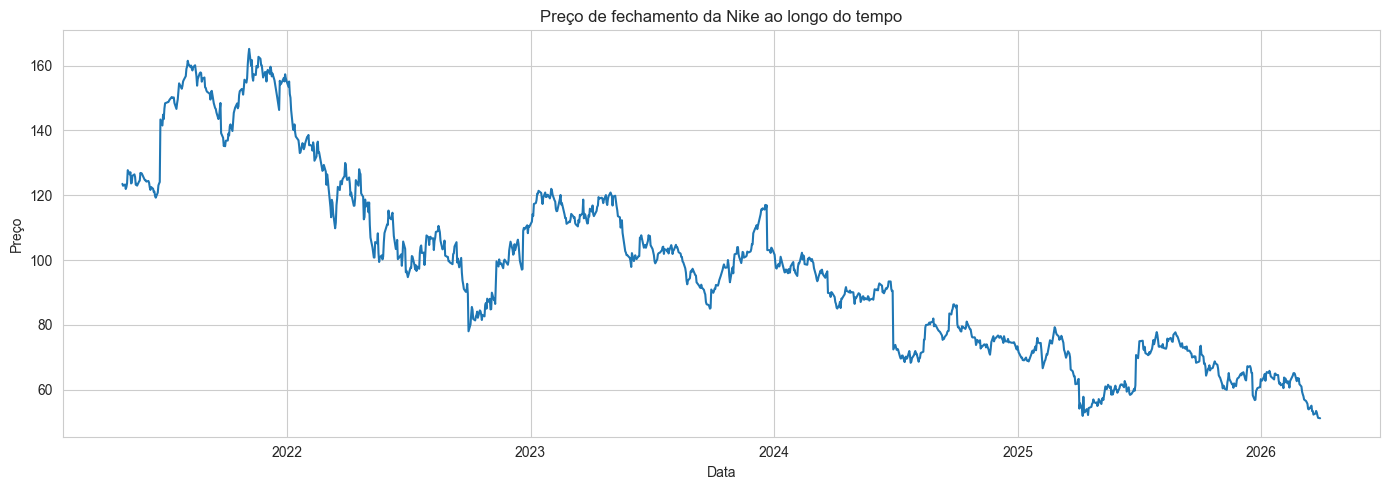

In [7]:
plt.figure(figsize=(14, 5))
plt.plot(df["date"], df["close"])
plt.title("Preço de fechamento da Nike ao longo do tempo")
plt.xlabel("Data")
plt.ylabel("Preço")
plt.tight_layout()
plt.show()

## Retornos Diários

Os retornos mostram a variação percentual do preço.
Eles ajudam a entender:
- Volatilidade
- Risco
- Ruído do mercado

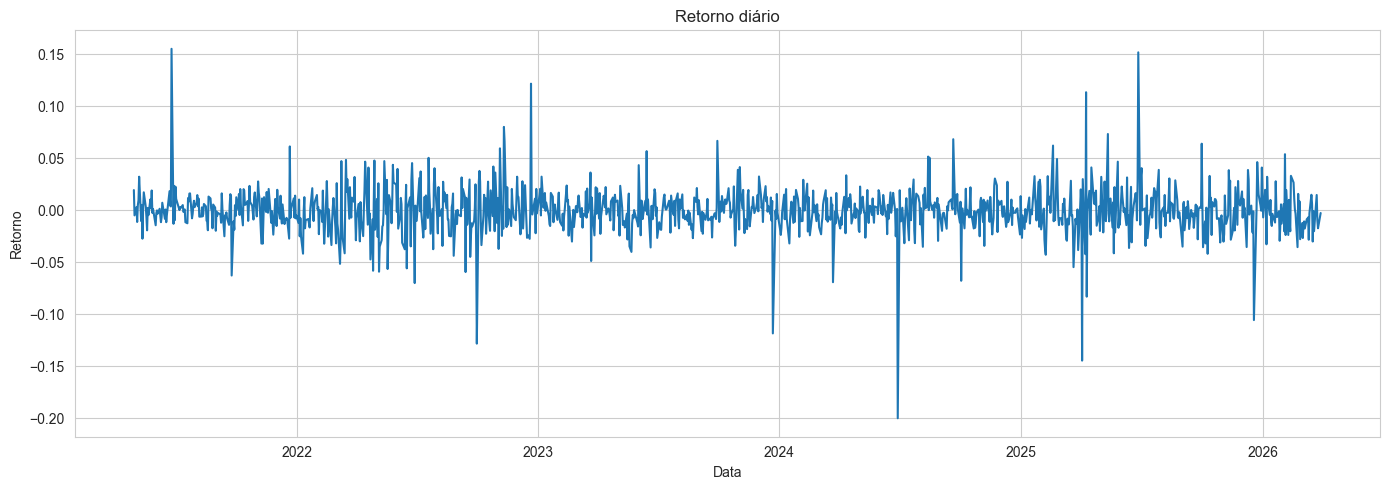

In [8]:
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(df["date"], df["return_1d"])
ax.set_title("Retorno diário")
ax.set_xlabel("Data")
ax.set_ylabel("Retorno")
plt.tight_layout()
plt.show()

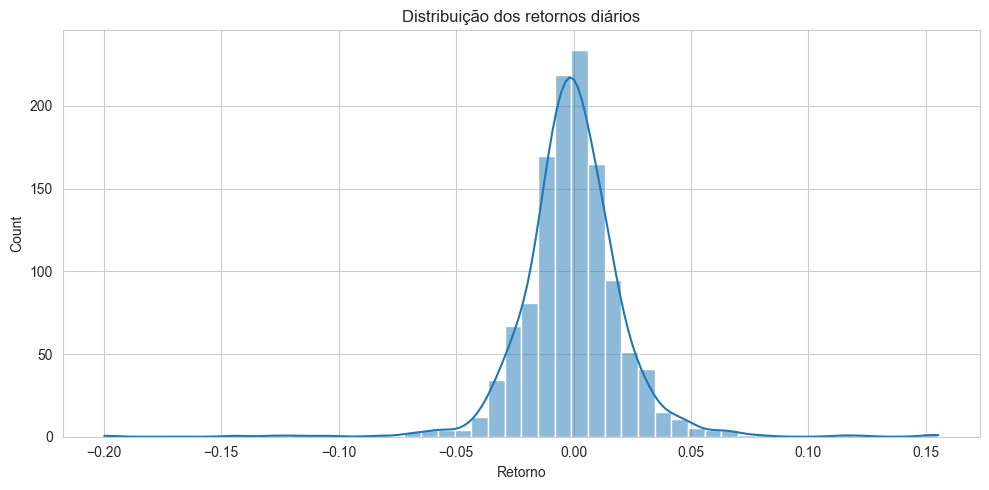

In [9]:
plt.figure(figsize=(10, 5))
sns.histplot(df["return_1d"], bins=50, kde=True)
plt.title("Distribuição dos retornos diários")
plt.xlabel("Retorno")
plt.tight_layout()
plt.show()

## Volatilidade

A volatilidade mede o grau de variação dos preços.

Alta volatilidade = maior risco e imprevisibilidade.

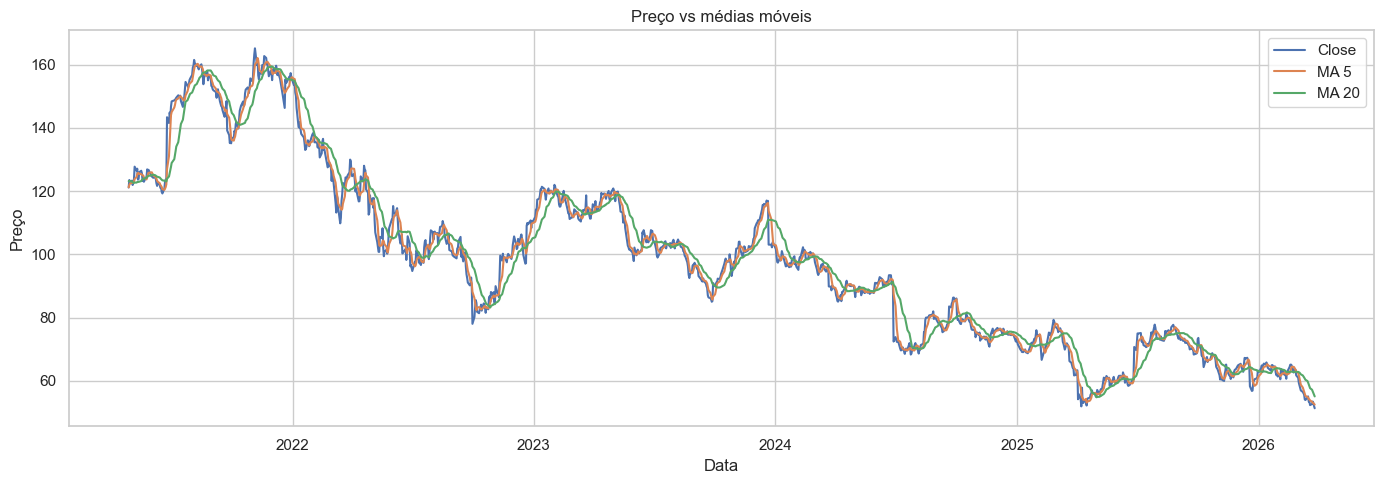

In [ ]:
plt.figure(figsize=(14, 5))
plt.plot(df["date"], df["close"], label="Close")
plt.plot(df["date"], df["ma_5"], label="MA 5")
plt.plot(df["date"], df["ma_20"], label="MA 20")
plt.title("Preço vs médias móveis")
plt.xlabel("Data")
plt.ylabel("Preço")
plt.legend()
plt.tight_layout()
plt.show()

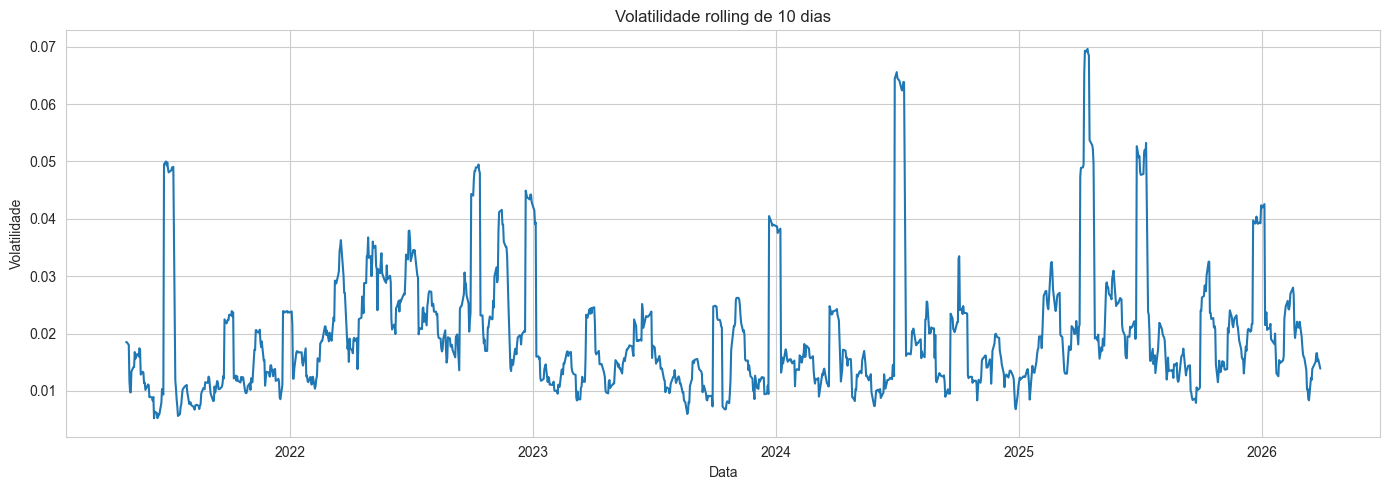

In [10]:
plt.figure(figsize=(14, 5))
plt.plot(df["date"], df["volatility_10"])
plt.title("Volatilidade rolling de 10 dias")
plt.xlabel("Data")
plt.ylabel("Volatilidade")
plt.tight_layout()
plt.show()

## Médias Móveis

As médias móveis ajudam a identificar tendências:
- MA5 → curto prazo
- MA20 → médio prazo


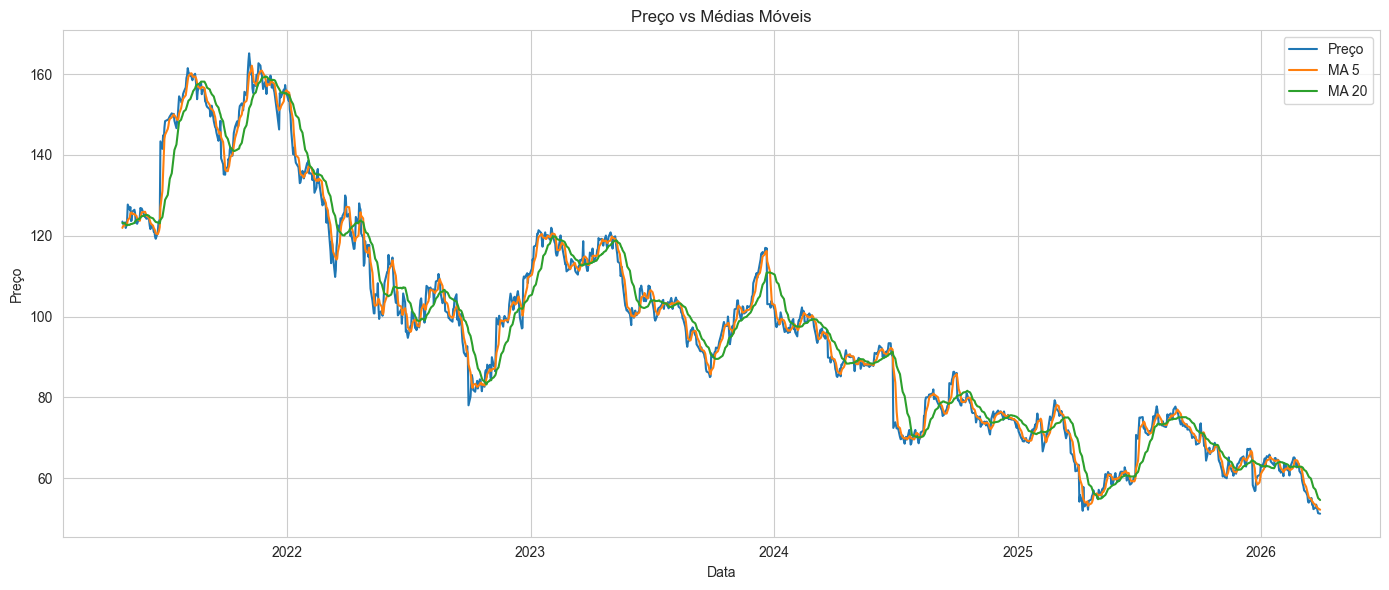

In [11]:
plt.figure(figsize=(14, 6))
plt.plot(df["date"], df["close"], label="Preço")
plt.plot(df["date"], df["ma_5"], label="MA 5")
plt.plot(df["date"], df["ma_20"], label="MA 20")
plt.legend()
plt.title("Preço vs Médias Móveis")
plt.xlabel("Data")
plt.ylabel("Preço")
plt.tight_layout()
plt.show()


## Correlação

Avalia o relacionamento entre variáveis criadas.

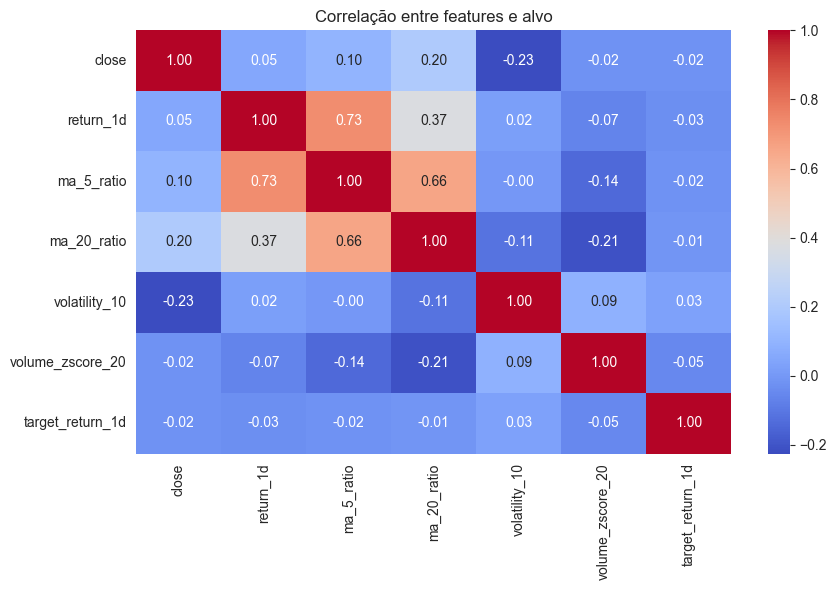

In [12]:
corr_cols = FEATURE_COLS_DEFAULT + ["target_return_1d"]
corr = df[corr_cols].corr()

plt.figure(figsize=(9, 6))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlação entre features e alvo")
plt.tight_layout()
plt.show()

## Insights Relevantes

A partir da análise exploratória, observamos:

### Tendência
- O preço apresenta comportamento temporal dependente (não estacionário)
- Isso reforça o uso de modelos sequenciais como LSTM

### Volatilidade
- O mercado apresenta períodos de alta volatilidade
- Isso aumenta a dificuldade de previsão

### Retornos
- Retornos são altamente ruidosos
- Modelos podem ter dificuldade em prever mudanças bruscas

### Médias Móveis
- Ajudam a suavizar o comportamento do preço
- Podem ser utilizadas como features adicionais

### Implicações para o modelo
- Necessidade de janela temporal (window_size)
- Uso de normalização
- Separação temporal de treino/validação/teste
- Evitar vazamento de dados

## Escolha do Modelo (LSTM)

A LSTM foi escolhida porque:

- Captura dependências temporais
- Considera histórico sequencial
- É adequada para séries temporais não lineares

### Limitações
- Sensível a hiperparâmetros
- Pode sofrer overfitting
- Não captura eventos externos (macroeconômicos)

### Estratégias adotadas
- Uso de janela temporal (60 dias)
- Normalização com MinMaxScaler
- Early stopping
- Validação temporal

## Próximos Passos

Com base na EDA:

1. Treinar modelo LSTM com o conjunto atual de features:
   - `close`
   - `return_1d`
   - `ma_5_ratio`
   - `ma_20_ratio`
   - `volatility_10`
   - `volume_zscore_20`
2. Comparar com baseline:
   - previsão ingênua (último valor)
3. Avaliar métricas:
   - RMSE, MAE, MAPE e direction accuracy
4. Evoluir para pipeline MLOps:
   - versionamento
   - monitoramento
   - deploy

---

Esta EDA fornece base para decisões de modelagem e arquitetura no projeto.
